# UNet (ResNet-50 encoder) — WaRP-S Semantic Segmentation
**Author:** Sayed Omar Aabid

---
### Architecture summary

| Component | Detail |
|---|---|
| Encoder | ResNet-50 (ImageNet-1k pretrained) |
| Skip connections | layer1 (256ch), layer2 (512ch), layer3 (1024ch), layer4 (2048ch) |
| Decoder | 4× bilinear upsample + skip concat + Conv-BN-ReLU×2 |
| Head | Dropout2d(0.1) → Conv2d(64 → NUM_CLASSES) |
| Output | Full-resolution logits (B, C, H, W) — same spatial size as input |
| Parameters | 32.5 M total |

In [1]:
import sys, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.metrics import confusion_matrix


root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Models.UNet import UNet

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device  : cuda
PyTorch : 2.5.1+cu121


## Paths & Labelmap

In [2]:
IMG_SIZE      = 384        # SegFormer / Mask2Former baseline used 384 — consistent
BATCH_SIZE    = 4
NUM_WORKERS   = 0
NUM_EPOCHS    = 80
WARMUP_EPOCHS = 20
HEAD_LR       = 1e-3
DECODER_LR    = 1e-4
BACKBONE_LR   = 1e-5
WEIGHT_DECAY  = 1e-4
IGNORE_INDEX  = 255        # boundary pixels marked in WaRP-S masks

# WaRP-S paths (same layout as SegFormer/Mask2Former notebooks)
WARP_S_ROOT   = root / 'Dataset/raw/WaRP-S'
if not WARP_S_ROOT.exists():
    WARP_S_ROOT = root / 'Dataset/raw/Warp-S'

IMAGESETS_TXT = WARP_S_ROOT / 'ImageSets/Segmentation/default.txt'
IMAGES_DIR    = WARP_S_ROOT / 'JPEGImages'
MASKS_DIR     = WARP_S_ROOT / 'SegmentationClass'
LABELMAP_FILE = WARP_S_ROOT / 'labelmap.txt'

print('WaRP-S root :', WARP_S_ROOT)
print('Images dir  :', IMAGES_DIR)
print('Masks dir   :', MASKS_DIR)
print('Labelmap    :', LABELMAP_FILE)

WaRP-S root : c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\raw\WaRP-S
Images dir  : c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\raw\WaRP-S\JPEGImages
Masks dir   : c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\raw\WaRP-S\SegmentationClass
Labelmap    : c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\raw\WaRP-S\labelmap.txt


In [3]:
# Parse labelmap.txt: lass names + RGB→class_id mapping
# Format: name:R,G,B:
class_names = []
rgb_to_id   = {}

with open(LABELMAP_FILE, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        name    = line.split(':')[0]
        rgb_str = line.split(':')[1].split('::')[0]
        r, g, b = map(int, rgb_str.split(','))
        rgb_to_id[(r, g, b)] = len(class_names)
        class_names.append(name)

NUM_CLASSES = len(class_names)
print(f'Found {NUM_CLASSES} classes:')
for i, n in enumerate(class_names):
    print(f'  {i:2d}: {n}')

Found 29 classes:
   0: background
   1: bottle-blue
   2: bottle-blue-full
   3: bottle-blue5l
   4: bottle-blue5l-full
   5: bottle-dark
   6: bottle-dark-full
   7: bottle-green
   8: bottle-green-full
   9: bottle-milk
  10: bottle-milk-full
  11: bottle-multicolor
  12: bottle-multicolorv-full
  13: bottle-oil
  14: bottle-oil-full
  15: bottle-transp
  16: bottle-transp-full
  17: bottle-yogurt
  18: canister
  19: cans
  20: detergent-box
  21: detergent-color
  22: detergent-transparent
  23: detergent-white
  24: glass-dark
  25: glass-green
  26: glass-transp
  27: juice-cardboard
  28: milk-cardboard


## Dataset & Dataloaders

In [4]:
# Load valid image IDs (image + mask both exist)
with open(IMAGESETS_TXT, 'r') as f:
    all_ids = [line.strip() for line in f if line.strip()]

valid_ids = [
    img_id for img_id in all_ids
    if (MASKS_DIR / f'{img_id}.png').exists() and
       (IMAGES_DIR / f'{img_id}.jpg').exists()
]

# 80/20 train/val split (no shuffling → deterministic with seed 42)
random.shuffle(valid_ids)
split       = int(0.8 * len(valid_ids))
train_ids   = valid_ids[:split]
val_ids     = valid_ids[split:]

print(f'Total valid IDs : {len(valid_ids)}')
print(f'Train           : {len(train_ids)}')
print(f'Val             : {len(val_ids)}')

Total valid IDs : 112
Train           : 89
Val             : 23


In [5]:

class WarpSDataset(Dataset):
    """
    WaRP-S segmentation dataset.

    Each sample: (image_tensor, mask_tensor)
      image : (3, H, W) float32 normalised with WaRP-C stats
      mask  : (H, W) int64 class indices  (255 = ignore boundary)

    Augmentation (train only):
      - Random horizontal flip
      - Random scale + crop (scale jitter 0.75–1.25 → crop to IMG_SIZE)
      - ColorJitter matching the WaRP-C 'strong' pipeline
    """

    # WaRP-C normalisation stats (from EDA — darker than ImageNet)
    MEAN = torch.tensor([0.337, 0.344, 0.350]).view(3, 1, 1)
    STD  = torch.tensor([0.216, 0.209, 0.218]).view(3, 1, 1)

    def __init__(self, img_ids, images_dir, masks_dir, rgb_to_id,
                 size=384, augment=False):
        self.img_ids    = img_ids
        self.images_dir = Path(images_dir)
        self.masks_dir  = Path(masks_dir)
        self.rgb_to_id  = rgb_to_id
        self.size       = size
        self.augment    = augment

    def __len__(self):
        return len(self.img_ids)

    def _rgb_mask_to_index(self, mask_pil: Image.Image) -> torch.Tensor:
        """Convert RGB mask PNG → (H, W) int64 class index tensor."""
        mask_np  = np.array(mask_pil.convert('RGB'))
        H, W, _  = mask_np.shape
        idx_mask = torch.full((H, W), fill_value=255, dtype=torch.int64)  # default = ignore
        for (r, g, b), cls_id in self.rgb_to_id.items():
            match = (
                (mask_np[:, :, 0] == r) &
                (mask_np[:, :, 1] == g) &
                (mask_np[:, :, 2] == b)
            )
            idx_mask[match] = cls_id
        return idx_mask
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        image  = Image.open(self.images_dir / f'{img_id}.jpg').convert('RGB')
        mask   = Image.open(self.masks_dir  / f'{img_id}.png')

        # Resize to target size
        image = TF.resize(image, (self.size, self.size), interpolation=Image.BILINEAR)
        mask  = TF.resize(mask,  (self.size, self.size), interpolation=Image.NEAREST)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)

            # Random scale jitter (0.75–1.25) → random crop back to size
            scale = 0.75 + random.random() * 0.5
            new_h = int(self.size * scale)
            new_w = int(self.size * scale)
            image = TF.resize(image, (new_h, new_w), interpolation=Image.BILINEAR)
            mask  = TF.resize(mask,  (new_h, new_w), interpolation=Image.NEAREST)
            # Pad if smaller than target
            pad_h = max(0, self.size - new_h)
            pad_w = max(0, self.size - new_w)
            if pad_h > 0 or pad_w > 0:
                image = TF.pad(image, [0, 0, pad_w, pad_h], fill=0)
                mask  = TF.pad(mask,  [0, 0, pad_w, pad_h], fill=255)
            # Random crop
            max_y = image.size[1] - self.size  # PIL: size is (W, H)
            max_x = image.size[0] - self.size
            i = random.randint(0, max_y)
            j = random.randint(0, max_x)
            image = TF.crop(image, i, j, self.size, self.size)
            mask  = TF.crop(mask,  i, j, self.size, self.size)

            # ColorJitter — matches WaRP-C 'strong' pipeline
            image = TF.adjust_brightness(image, 1 + (random.random() - 0.5) * 0.8)
            image = TF.adjust_contrast(image,   1 + (random.random() - 0.5) * 0.6)
            image = TF.adjust_saturation(image, 1 + (random.random() - 0.5) * 0.6)

        # To tensor + normalise
        image_t = TF.to_tensor(image)               # (3, H, W) float32 [0,1]
        image_t = (image_t - self.MEAN) / self.STD  # WaRP-C normalisation

        mask_t = self._rgb_mask_to_index(mask)       # (H, W) int64

        return image_t, mask_t

    
train_dataset = WarpSDataset(
    train_ids, IMAGES_DIR, MASKS_DIR, rgb_to_id, size=IMG_SIZE, augment=True
)
val_dataset   = WarpSDataset(
    val_ids,   IMAGES_DIR, MASKS_DIR, rgb_to_id, size=IMG_SIZE, augment=False
)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                            shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train batches : 23
Val   batches : 6


## Model

In [6]:
model = UNet(
    num_classes = NUM_CLASSES,
    dropout     = 0.1,
    freeze      = True,       #
    pretrained  = True,
).to(DEVICE)

# Sanity check — forward pass
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}  ← should be (2, {NUM_CLASSES}, {IMG_SIZE}, {IMG_SIZE})')
print()
print(model)

Input  : torch.Size([2, 3, 384, 384])
Output : torch.Size([2, 29, 384, 384])  ← should be (2, 29, 384, 384)

UNet-ResNet50
  num_classes     : 29
  dropout         : 0.1
  total params    : 43.9M
  trainable params: 20.39M
  encoder         : ResNet-50 (ImageNet-1k V1)
  decoder         : 4× DecoderBlock (bilinear upsample + skip concat)
  head            : Dropout2d(0.1) → Conv2d(64→29)


## Loss & Metrics

In [7]:
# Compute per-class pixel counts from training masks for weighted loss
# (same imbalance-handling philosophy as WaRP-C classification)
print('Computing class pixel frequencies from training set...')
pixel_counts = torch.zeros(NUM_CLASSES)

for _, mask_t in train_dataset:
    valid = mask_t[mask_t != 255]
    for c in range(NUM_CLASSES):
        pixel_counts[c] += (valid == c).sum()

# Inverse-frequency weights, clipped for numerical stability
pixel_counts = pixel_counts.clamp(min=1.0)
class_weights = (1.0 / pixel_counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES   # normalise
class_weights = class_weights.to(DEVICE)

print('Class pixel weights (top 5 rarest):')
top5 = class_weights.argsort(descending=True)[:5]
for i in top5:
    print(f'  {class_names[i]:30s}  weight={class_weights[i]:.4f}  pixels={int(pixel_counts[i])}')

Computing class pixel frequencies from training set...
Class pixel weights (top 5 rarest):
  background                      weight=28.9957  pixels=1
  bottle-green                    weight=0.0007  pixels=39804
  bottle-green-full               weight=0.0002  pixels=122330
  bottle-blue                     weight=0.0002  pixels=141265
  bottle-dark-full                weight=0.0002  pixels=157007


In [8]:
# Phase 1 loss: weighted CE — addresses class imbalance during warm-up
# Phase 2 loss: unweighted CE — let the encoder adapt without bias
criterion_p1 = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
criterion_p2 = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
criterion    = criterion_p1

def compute_miou(preds: torch.Tensor, labels: torch.Tensor,
                 num_classes: int, ignore_index: int = 255) -> float:
    """
    Compute mean IoU over all classes, ignoring `ignore_index` pixels.

    Parameters
    ----------
    preds  : (N,) or (B, H, W) int64 predicted class indices
    labels : same shape, int64 ground truth

    Returns
    -------
    mIoU as float (0–1)
    """
    preds  = preds.view(-1)
    labels = labels.view(-1)

    # Remove ignore pixels
    valid  = labels != ignore_index
    preds  = preds[valid]
    labels = labels[valid]

    ious = []
    for cls in range(num_classes):
        pred_c  = preds  == cls
        label_c = labels == cls
        inter   = (pred_c & label_c).sum().item()
        union   = (pred_c | label_c).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0

print('Loss and metrics defined.')

Loss and metrics defined.


## Training Configuration

In [9]:
# Phase 1: train decoder + head only (encoder frozen)
decoder_params = [
    model.decoder4, model.decoder3, model.decoder2, model.decoder1,
    model.final_up, model.head
]
p1_params = [p for m in decoder_params for p in m.parameters()]

optimizer    = torch.optim.AdamW(p1_params, lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS)
scaler       = GradScaler(enabled=(DEVICE == 'cuda'))

print(f'Epochs    : {NUM_EPOCHS}  (Phase 1: 1-{WARMUP_EPOCHS}, Phase 2: {WARMUP_EPOCHS+1}-{NUM_EPOCHS})')
print(f'Phase 1   : decoder + head only  LR={HEAD_LR}')
print(f'Phase 2   : backbone LR={BACKBONE_LR}, decoder LR={DECODER_LR}')

Epochs    : 80  (Phase 1: 1-20, Phase 2: 21-80)
Phase 1   : decoder + head only  LR=0.001
Phase 2   : backbone LR=1e-05, decoder LR=0.0001


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_11460\2889437503.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler(enabled=(DEVICE == 'cuda'))


## Training Loop

In [10]:
def evaluate(model, loader, device, num_classes, ignore_index=255):
    """Evaluate mIoU on a dataloader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            logits = model(images)                        # (B, C, H, W)
            preds  = logits.argmax(dim=1).cpu()           # (B, H, W)
            all_preds.append(preds.view(-1))
            all_labels.append(masks.view(-1))
    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return compute_miou(all_preds, all_labels, num_classes, ignore_index)


train_losses  = []
train_mious   = []
val_mious     = []
best_miou     = 0.0
best_path     = root / 'Models/weights/unet_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):

    # Phase transition 
    if epoch == WARMUP_EPOCHS + 1:
        model.unfreeze()
        print(f'\n→ Phase 2 started at epoch {epoch}')
        optimizer = torch.optim.AdamW([
            {'params': [p for m in decoder_params for p in m.parameters()],
             'lr': DECODER_LR},
            {'params': list(model.encoder_stem.parameters()) +
                       list(model.encoder_pool.parameters()) +
                       list(model.encoder1.parameters()) +
                       list(model.encoder2.parameters()) +
                       list(model.encoder3.parameters()) +
                       list(model.encoder4.parameters()),
             'lr': BACKBONE_LR},
        ], weight_decay=WEIGHT_DECAY)
        scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )
        criterion = criterion_p2
        print(f'  Loss      → unweighted CrossEntropyLoss(ignore_index=255)')
        print(f'  Decoder LR={DECODER_LR}  Backbone LR={BACKBONE_LR}\n')

    # Train one epoch 
    model.train()
    epoch_loss = 0.0
    batch_preds, batch_labels = [], []
    t0 = time.time()

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = model(images)              # (B, C, H, W)
            loss   = criterion(logits, masks)   # masks: (B, H, W) int64

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * images.size(0)
        preds = logits.detach().argmax(dim=1).cpu()
        batch_preds.append(preds.view(-1))
        batch_labels.append(masks.cpu().view(-1))

    (scheduler_p1 if epoch <= WARMUP_EPOCHS else scheduler_p2).step()

    avg_loss   = epoch_loss / len(train_dataset)
    train_miou = compute_miou(
        torch.cat(batch_preds), torch.cat(batch_labels),
        NUM_CLASSES, IGNORE_INDEX
    )
    val_miou = evaluate(model, val_loader, DEVICE, NUM_CLASSES, IGNORE_INDEX)

    train_losses.append(avg_loss)
    train_mious.append(train_miou)
    val_mious.append(val_miou)

    flag = ''
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), best_path)
        flag = ' ← best'

    phase = 1 if epoch <= WARMUP_EPOCHS else 2
    lr    = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} [P{phase}] | loss={avg_loss:.4f} | '
          f'train_mIoU={train_miou:.4f} | val_mIoU={val_miou:.4f} | '
          f'best={best_miou:.4f} | lr={lr:.2e} | t={time.time()-t0:.1f}s{flag}')

print(f'\nBest val mIoU : {best_miou:.4f}')
print(f'Weights saved → {best_path}')

C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_11460\2330898577.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch   1/80 [P1] | loss=3.4617 | train_mIoU=0.0043 | val_mIoU=0.0030 | best=0.0030 | lr=9.94e-04 | t=11.8s ← best
Epoch   2/80 [P1] | loss=3.3658 | train_mIoU=0.0054 | val_mIoU=0.0033 | best=0.0033 | lr=9.76e-04 | t=10.5s ← best
Epoch   3/80 [P1] | loss=3.3069 | train_mIoU=0.0088 | val_mIoU=0.0076 | best=0.0076 | lr=9.46e-04 | t=10.1s ← best
Epoch   4/80 [P1] | loss=3.2677 | train_mIoU=0.0116 | val_mIoU=0.0175 | best=0.0175 | lr=9.05e-04 | t=9.7s ← best
Epoch   5/80 [P1] | loss=3.2815 | train_mIoU=0.0103 | val_mIoU=0.0105 | best=0.0175 | lr=8.54e-04 | t=9.8s
Epoch   6/80 [P1] | loss=3.2242 | train_mIoU=0.0172 | val_mIoU=0.0128 | best=0.0175 | lr=7.94e-04 | t=9.8s
Epoch   7/80 [P1] | loss=3.1663 | train_mIoU=0.0210 | val_mIoU=0.0119 | best=0.0175 | lr=7.27e-04 | t=9.9s
Epoch   8/80 [P1] | loss=3.1201 | train_mIoU=0.0260 | val_mIoU=0.0247 | best=0.0247 | lr=6.55e-04 | t=9.7s ← best
Epoch   9/80 [P1] | loss=3.0620 | train_mIoU=0.0365 | val_mIoU=0.0246 | best=0.0247 | lr=5.78e-04 | t=9.5s

## Training Curves

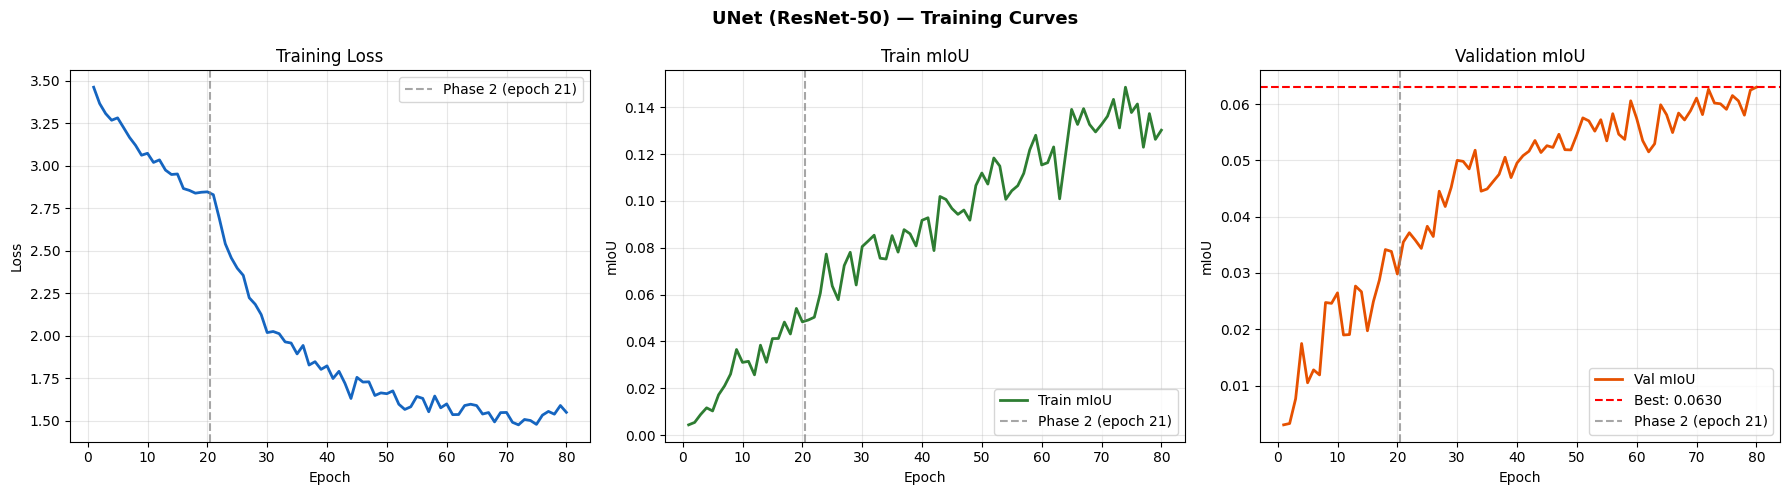

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UNet (ResNet-50) — Training Curves', fontsize=13, fontweight='bold')

epochs     = range(1, NUM_EPOCHS + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7,
                  label=f'Phase 2 (epoch {WARMUP_EPOCHS+1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_mious, '#2E7D32', linewidth=2, label='Train mIoU')
axes[1].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='mIoU', title='Train mIoU')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, val_mious, '#E65100', linewidth=2, label='Val mIoU')
axes[2].axhline(best_miou, color='red', linestyle='--', label=f'Best: {best_miou:.4f}')
axes[2].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='mIoU', title='Validation mIoU')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/unet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation (Per-Class IoU)

In [12]:
# Load best weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

all_preds_flat  = []
all_labels_flat = []

with torch.no_grad():
    for images, masks in val_loader:
        logits = model(images.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu()
        all_preds_flat.append(preds.view(-1))
        all_labels_flat.append(masks.view(-1))

all_preds_flat  = torch.cat(all_preds_flat)
all_labels_flat = torch.cat(all_labels_flat)

# Per-class IoU
valid_mask  = all_labels_flat != IGNORE_INDEX
preds_valid = all_preds_flat[valid_mask]
lbls_valid  = all_labels_flat[valid_mask]

per_class_iou = {}
for cls in range(NUM_CLASSES):
    pred_c  = preds_valid == cls
    label_c = lbls_valid  == cls
    inter   = (pred_c & label_c).sum().item()
    union   = (pred_c | label_c).sum().item()
    per_class_iou[class_names[cls]] = inter / union if union > 0 else float('nan')

final_miou = np.nanmean(list(per_class_iou.values()))

print(f'Final Val mIoU : {final_miou:.4f}\n')
print(f'{"Class":<30} IoU')
print('-' * 42)
for name, iou in sorted(per_class_iou.items(), key=lambda x: x[1] if not np.isnan(x[1]) else -1, reverse=True):
    bar = '█' * int(iou * 30) if not np.isnan(iou) else ''
    print(f'{name:<30} {iou:.4f}  {bar}')

Final Val mIoU : 0.0630

Class                          IoU
------------------------------------------
bottle-dark                    0.6988  ████████████████████
bottle-dark-full               0.2798  ████████
detergent-color                0.2184  ██████
glass-dark                     0.2158  ██████
glass-green                    0.1655  ████
bottle-green-full              0.1146  ███
bottle-oil                     0.0532  █
bottle-blue5l-full             0.0165  
bottle-blue5l                  0.0008  
bottle-blue                    0.0000  
bottle-blue-full               0.0000  
bottle-green                   0.0000  
bottle-milk                    0.0000  
bottle-milk-full               0.0000  
bottle-multicolor              0.0000  
bottle-multicolorv-full        0.0000  
bottle-oil-full                0.0000  
bottle-transp                  0.0000  
bottle-transp-full             0.0000  
bottle-yogurt                  0.0000  
canister                       0.0000  
cans     

## Visual Predictions

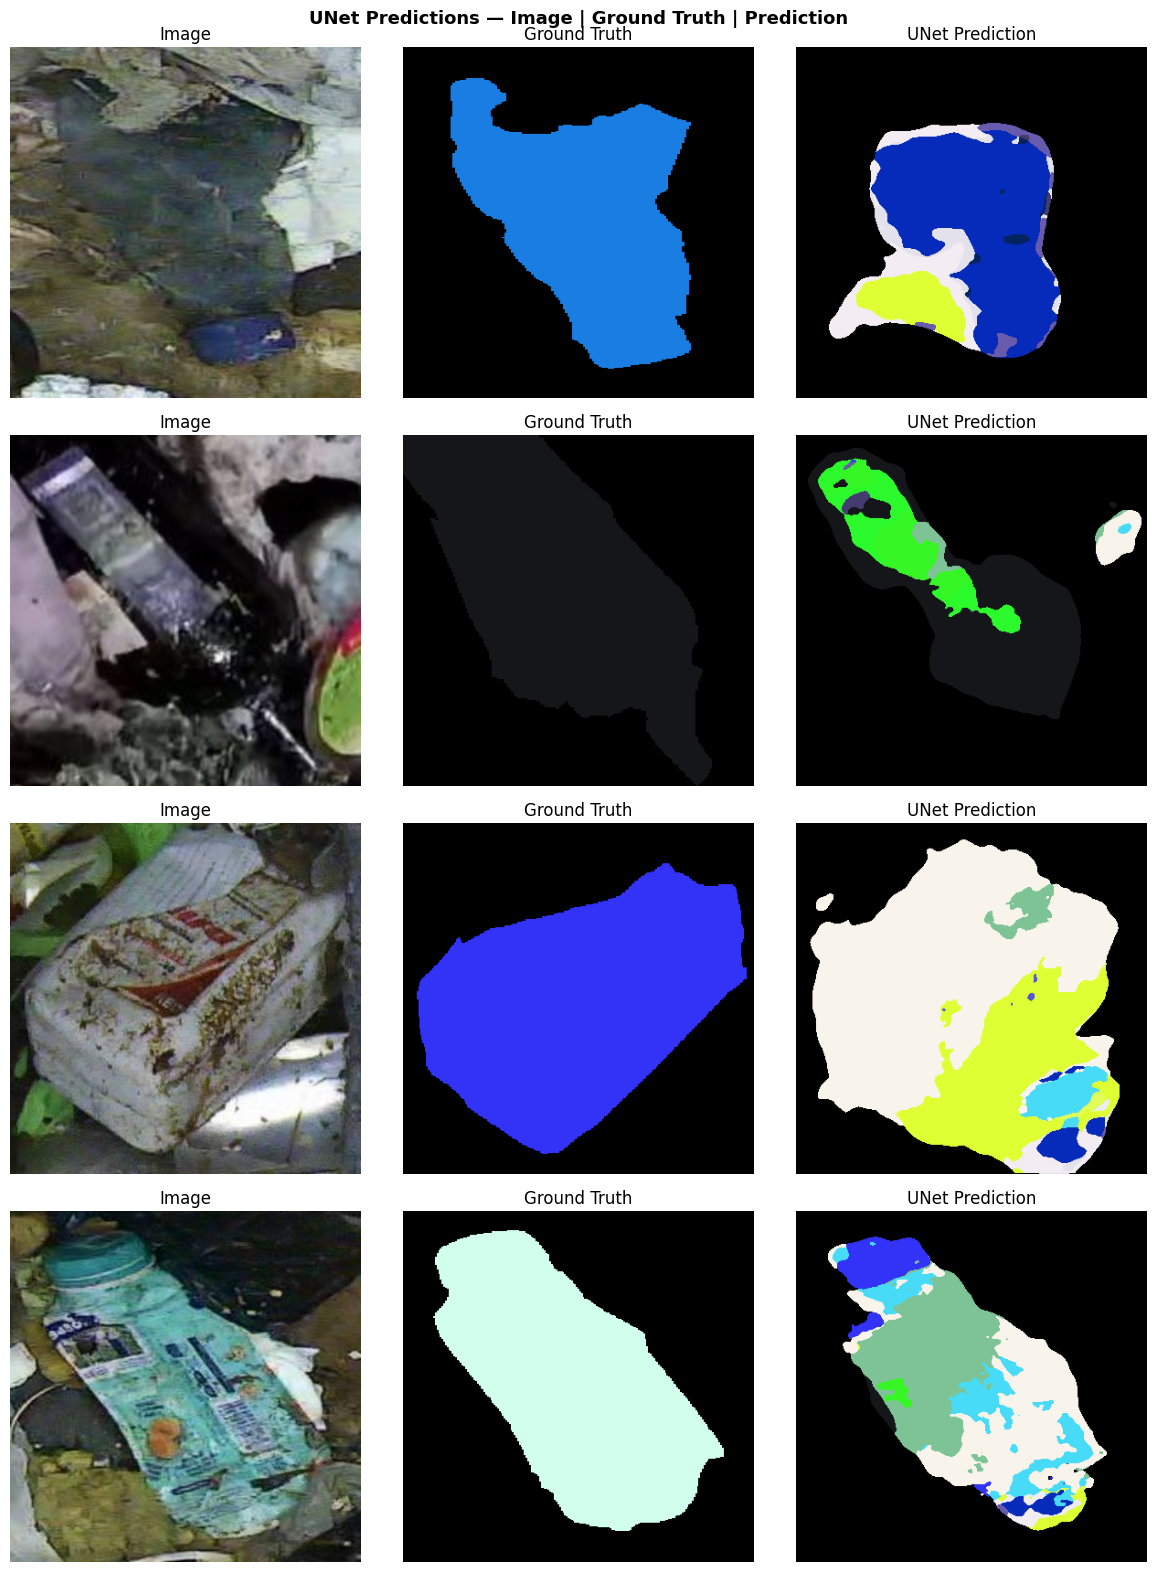

In [13]:
# Build colour map from labelmap for visualisation
id_to_rgb = {v: k for k, v in rgb_to_id.items()}

def mask_to_rgb(mask: np.ndarray) -> np.ndarray:
    """Convert (H, W) class index mask to (H, W, 3) uint8 RGB for display."""
    H, W    = mask.shape
    rgb_out = np.zeros((H, W, 3), dtype=np.uint8)
    for cls_id, (r, g, b) in id_to_rgb.items():
        rgb_out[mask == cls_id] = [r, g, b]
    return rgb_out

# Denormalise for display
MEAN_np = np.array([0.337, 0.344, 0.350]).reshape(3, 1, 1)
STD_np  = np.array([0.216, 0.209, 0.218]).reshape(3, 1, 1)

def denorm(tensor):
    img = tensor.numpy() * STD_np + MEAN_np
    return np.clip(img.transpose(1, 2, 0), 0, 1)


model.eval()
num_show = 4
fig, axes = plt.subplots(num_show, 3, figsize=(12, num_show * 4))
fig.suptitle('UNet Predictions — Image | Ground Truth | Prediction', fontsize=13, fontweight='bold')

sample_indices = random.sample(range(len(val_dataset)), num_show)

for row, idx in enumerate(sample_indices):
    img_t, mask_t = val_dataset[idx]

    with torch.no_grad():
        logit = model(img_t.unsqueeze(0).to(DEVICE))
        pred  = logit.argmax(dim=1).squeeze(0).cpu().numpy()

    axes[row, 0].imshow(denorm(img_t))
    axes[row, 0].set_title('Image')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_to_rgb(mask_t.numpy()))
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(mask_to_rgb(pred))
    axes[row, 2].set_title('UNet Prediction')
    axes[row, 2].axis('off')

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/unet_visual_predictions.png', dpi=150, bbox_inches='tight')
plt.show()